<a href="https://colab.research.google.com/github/azrasm/waste-classification/blob/main/Implementacija_modela.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projekat (LV7) - **Implementacija modela**

## Priprema i učitavanje dataseta

In [ ]:
import tensorflow as tf
from keras import layers, models, optimizers, callbacks, applications
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import itertools
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# === SETUP ===
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Ova funkcija je generator koji učitava .npz batch-eve i pretvara u manjie mini-batch-e (16) kako ne bismo učitavali veliku količinu u memoriju.

In [ ]:
def batch_generator(batch_dir, batch_size=16):
    batch_files = sorted(f for f in os.listdir(batch_dir) if f.endswith(".npz"))

    while True:
        for bf in batch_files:
            data = np.load(os.path.join(batch_dir, bf))
            X, y = data["X"], data["y"]

            for i in range(0, len(X), batch_size):
                yield X[i:i+batch_size], y[i:i+batch_size]

## Treniranje 1.

Prvo testiranje je urađeno sa 15 epoha treniranja koristeći transfer learning sa zamrznutim osnovnim slojevima ResNet50 modela i treniranjem dodatne klasifikacione glave.

In [ ]:
train_dir = "/content/drive/MyDrive/POOS projekat/PROCESSED_DATASET/TRAIN"
val_dir   = "/content/drive/MyDrive/POOS projekat/PROCESSED_DATASET/VAL"
test_dir  = "/content/drive/MyDrive/POOS projekat/PROCESSED_DATASET/TEST"

train_gen = batch_generator(train_dir, batch_size=16)
val_gen   = batch_generator(val_dir, batch_size=16)
test_gen  = batch_generator(test_dir, batch_size=16)

steps_per_epoch = sum(len(np.load(os.path.join(train_dir, f))["X"]) for f in os.listdir(train_dir)) // 16
validation_steps = sum(len(np.load(os.path.join(val_dir, f))["X"]) for f in os.listdir(val_dir)) // 16
test_steps = sum(len(np.load(os.path.join(test_dir, f))["X"]) for f in os.listdir(test_dir)) // 16

In [ ]:
#DEFINICIJA RESNET50 MODELA

from keras.applications import ResNet50
from keras.layers import Dense, GlobalAveragePooling2D, Dropout
from keras.models import Model
from keras.optimizers import Adam

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Zamrzavanje osnovnih slojeva (transfer learning)
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
#KOMPILACIJA MODELA

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
#TRENIRANJE MODELA

epochs = 15

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=epochs
)

Epoch 1/15
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 138s 97ms/step - accuracy: 0.6054 - loss: 0.6632 - val_accuracy: 0.6995 - val_loss: 0.5932
Epoch 2/15
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 118s 92ms/step - accuracy: 0.6796 - loss: 0.6022 - val_accuracy: 0.7119 - val_loss: 0.5840
Epoch 3/15
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 118s 91ms/step - accuracy: 0.6854 - loss: 0.5930 - val_accuracy: 0.7163 - val_loss: 0.5783
Epoch 4/15
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 117s 91ms/step - accuracy: 0.6980 - loss: 0.5822 - val_accuracy: 0.7223 - val_loss: 0.5727
Epoch 5/15
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 141s 110ms/step - accuracy: 0.7070 - loss: 0.5732 - val_accuracy: 0.7309 - val_loss: 0.5674
Epoch 6/15
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 115s 89ms/step - accuracy: 0.7100 - loss: 0.5682 - val_accuracy: 0.7296 - val_loss: 0.5691
Epoch 7/15
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 116s 90ms/step - accuracy: 0.7194 - loss: 0.5623 - val_accuracy: 0.7469 - val_loss: 0.5538
Epoch 8/15
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 115s 89ms/step - accuracy:

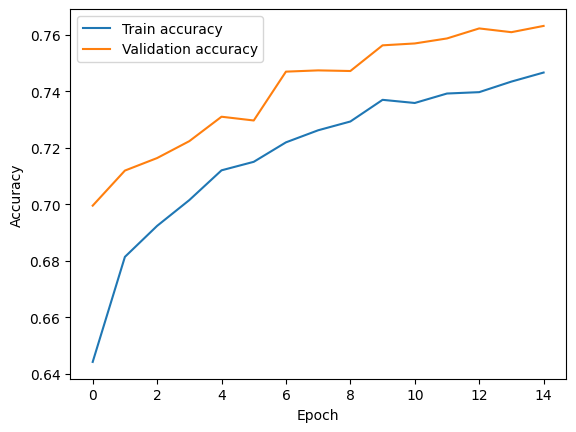

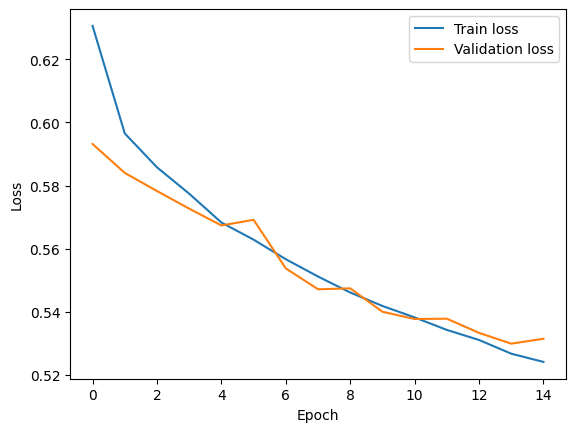

In [ ]:
#PRAĆENJE PERFORMANSI

plt.figure()
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
#EVALUACIJA NA TEST SKUPU

test_loss, test_accuracy = model.evaluate(
    test_gen,
    steps=test_steps
)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.7997 - loss: 0.5116
Test accuracy: 0.7862260937690735
Test loss: 0.4911291003227234


In [ ]:
#Spašavanje modela

model.save("/content/drive/MyDrive/POOS projekat/resnet50_waste_classifier_2.keras")

### Rezultati

Tačnost se poboljšava i na zadnjoj epohi, što znači da je treniranje prekinuto prerano.

## Treniranje 2: Više epoha

Za ovo testiranje je dodato rano zaustavljanje sa patience=5 kako bi se treniranje automatski prekinulo ako se validacioni gubitak ne poboljšava pet uzastopnih epoha, uz povećanje maksimalnog broja epoha na 30 za potencijalno bolje učenje.

In [ ]:
from keras.callbacks import EarlyStopping

# Definisanje ranog zaustavljanja
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history2 = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=30,
    callbacks=[early_stop]
)


Epoch 1/30
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 107s 83ms/step - accuracy: 0.7459 - loss: 0.5248 - val_accuracy: 0.7680 - val_loss: 0.5264
Epoch 2/30
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 105s 82ms/step - accuracy: 0.7499 - loss: 0.5224 - val_accuracy: 0.7622 - val_loss: 0.5294
Epoch 3/30
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 140s 109ms/step - accuracy: 0.7539 - loss: 0.5180 - val_accuracy: 0.7648 - val_loss: 0.5287
Epoch 4/30
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 102s 80ms/step - accuracy: 0.7562 - loss: 0.5167 - val_accuracy: 0.7655 - val_loss: 0.5264
Epoch 5/30
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 103s 80ms/step - accuracy: 0.7551 - loss: 0.5130 - val_accuracy: 0.7662 - val_loss: 0.5249
Epoch 6/30
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 104s 81ms/step - accuracy: 0.7606 - loss: 0.5126 - val_accuracy: 0.7677 - val_loss: 0.5204
Epoch 7/30
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 103s 80ms/step - accuracy: 0.7618 - loss: 0.5094 - val_accuracy: 0.7664 - val_loss: 0.5220
Epoch 8/30
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 103s 80ms/step - accuracy:

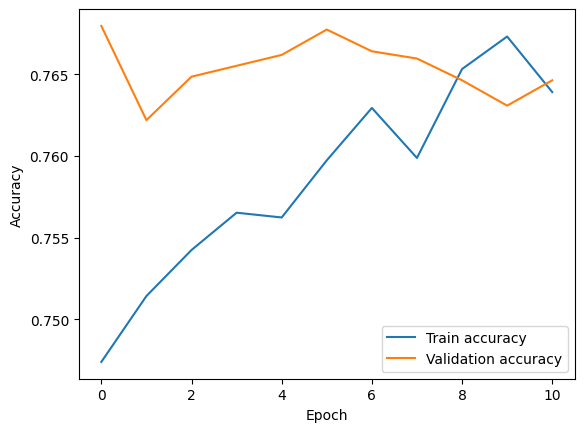

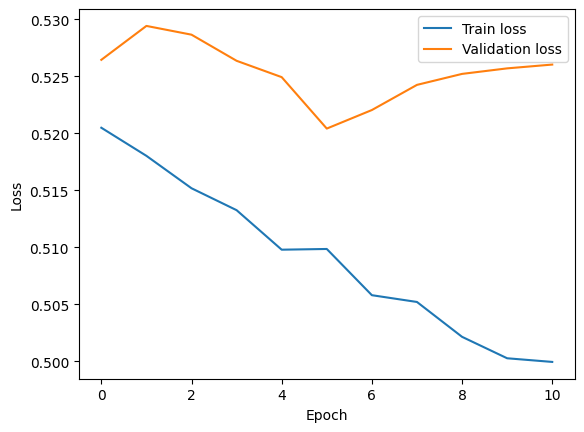

In [ ]:
#PRAĆENJE PERFORMANSI

plt.figure()
plt.plot(history2.history["accuracy"], label="Train accuracy")
plt.plot(history2.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history2.history["loss"], label="Train loss")
plt.plot(history2.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
#EVALUACIJA NA TEST SKUPU

test_loss, test_accuracy = model.evaluate(
    test_gen,
    steps=test_steps
)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - accuracy: 0.8104 - loss: 0.4812
Test accuracy: 0.7889467477798462
Test loss: 0.4817800521850586


### Rezultati

* Treniranje se zaustavlja na 17. epohi, najbolji rezultati na 11. epohi.
* Tačnost se povećala na 79%.
* Model se čini nestabilnim

In [ ]:
#Spašavanje modela

model.save("/content/drive/MyDrive/POOS projekat/resnet50_waste_classifier_30epochs.keras")

## Treniranje 3: Namještanje slojeva i parametara

Za ovo testiranje zadnjih 15 slojeva ResNet50 je otključano i uvedena je  manja stopa učenja (1e-6) kako bi se pokušali povećati tačnost i stabilizitali model.

In [ ]:
# Otključavanje zadnjih 15 slojeva
for layer in base_model.layers[-15:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_param = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=30,
    callbacks=[early_stop]
)


Epoch 1/30
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 129s 88ms/step - accuracy: 0.6244 - loss: 2.8287 - val_accuracy: 0.7030 - val_loss: 0.9065
Epoch 2/30
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 98s 76ms/step - accuracy: 0.7141 - loss: 0.5800 - val_accuracy: 0.7323 - val_loss: 0.7392
Epoch 3/30
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 97s 76ms/step - accuracy: 0.7440 - loss: 0.5348 - val_accuracy: 0.7500 - val_loss: 0.6707
Epoch 4/30
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 99s 77ms/step - accuracy: 0.7659 - loss: 0.4975 - val_accuracy: 0.7560 - val_loss: 0.6502
Epoch 5/30
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 98s 76ms/step - accuracy: 0.7864 - loss: 0.4718 - val_accuracy: 0.7582 - val_loss: 0.6465
Epoch 6/30
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 99s 77ms/step - accuracy: 0.8005 - loss: 0.4426 - val_accuracy: 0.7595 - val_loss: 0.6490
Epoch 7/30
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 98s 76ms/step - accuracy: 0.8155 - loss: 0.4193 - val_accuracy: 0.7580 - val_loss: 0.6571
Epoch 8/30
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 100s 78ms/step - accuracy: 0.8243

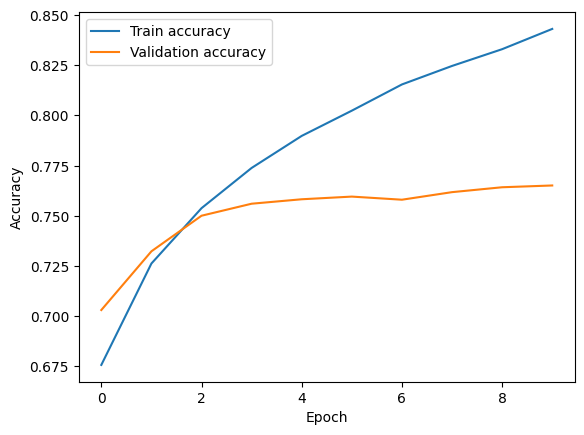

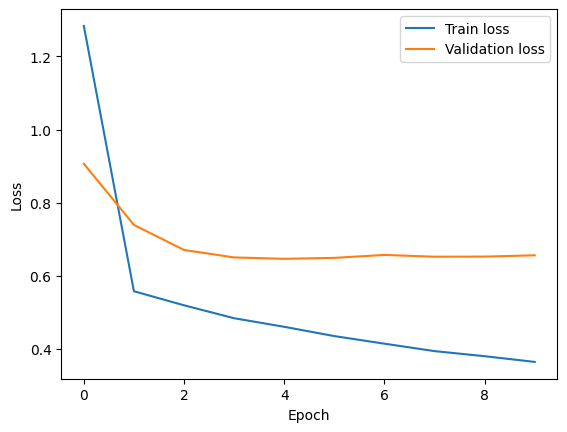

In [ ]:
#PRAĆENJE PERFORMANSI

plt.figure()
plt.plot(history_param.history["accuracy"], label="Train accuracy")
plt.plot(history_param.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history_param.history["loss"], label="Train loss")
plt.plot(history_param.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
#EVALUACIJA NA TEST SKUPU

test_loss, test_accuracy = model.evaluate(
    test_gen,
    steps=test_steps
)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - accuracy: 0.7871 - loss: 0.6111
Test accuracy: 0.774929940700531
Test loss: 0.5980615019798279


In [ ]:
#Spašavanje modela

model.save("/content/drive/MyDrive/POOS projekat/resnet50_waste_classifier_namjestanje.keras")

### Rezultati:

Model prebrzo uči i počinje učiti napamet.

## Testiranje 4: Stopa učenja

Ponovo su zaključani svi slojevi ResNet50 dok je stopa učenja povećana na 1e-5, a broj epoha je povećan na 50.

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Zamrzavanje osnovnih slojeva (transfer learning)
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_lr = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 122s 86ms/step - accuracy: 0.5315 - loss: 0.7702 - val_accuracy: 0.6600 - val_loss: 0.6272
Epoch 2/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 98s 76ms/step - accuracy: 0.6132 - loss: 0.6627 - val_accuracy: 0.6680 - val_loss: 0.6171
Epoch 3/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 98s 76ms/step - accuracy: 0.6411 - loss: 0.6305 - val_accuracy: 0.6775 - val_loss: 0.6093
Epoch 4/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 99s 77ms/step - accuracy: 0.6581 - loss: 0.6190 - val_accuracy: 0.6773 - val_loss: 0.6043
Epoch 5/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 99s 77ms/step - accuracy: 0.6637 - loss: 0.6106 - val_accuracy: 0.6837 - val_loss: 0.5994
Epoch 6/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 98s 76ms/step - accuracy: 0.6738 - loss: 0.6060 - val_accuracy: 0.6879 - val_loss: 0.5957
Epoch 7/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 139s 108ms/step - accuracy: 0.6782 - loss: 0.6011 - val_accuracy: 0.6899 - val_loss: 0.5927
Epoch 8/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 99s 77ms/step - accuracy: 0.683

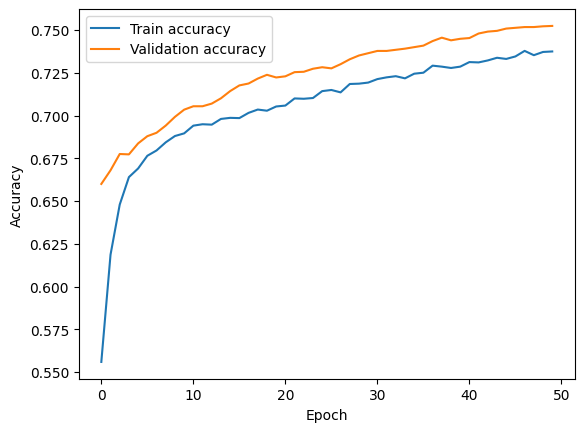

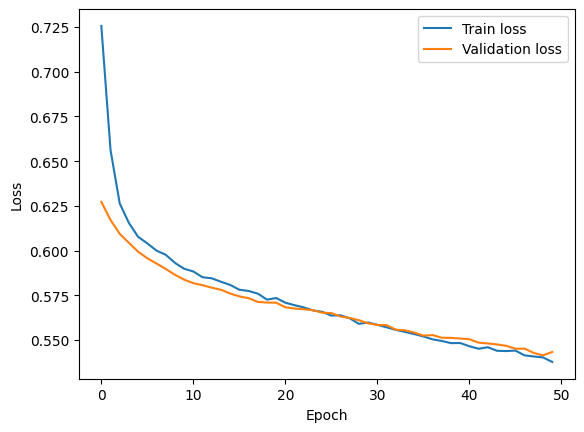

In [ ]:
#PRAĆENJE PERFORMANSI

plt.figure()
plt.plot(history_lr.history["accuracy"], label="Train accuracy")
plt.plot(history_lr.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history_lr.history["loss"], label="Train loss")
plt.plot(history_lr.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
#EVALUACIJA NA TEST SKUPU

test_loss, test_accuracy = model.evaluate(
    test_gen,
    steps=test_steps
)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 98ms/step - accuracy: 0.7588 - loss: 0.5249
Test accuracy: 0.7737284898757935
Test loss: 0.4983595609664917


### Rezultati

* Puno više vremena na treniranju
* Tačnost i loss su skoro isti ostali
* Model je dosta stabilniji

## Testiranje 5: Manje slike

Iako ResNet50 nije namjenjen za slike manje od 224 x 224, ipak smo htjeli trenirati na slikama manje veličine (128 x 128) u pokušaju da smanjimo vrijeme treniranja. Stopa učenja je povećana na 1e-4 a broj epoha je ostavljen na 50.

In [ ]:
train_dir128 = "/content/drive/MyDrive/POOS projekat/PROCESSED_DATASET128/TRAIN"
val_dir128   = "/content/drive/MyDrive/POOS projekat/PROCESSED_DATASET128/VAL"
test_dir128  = "/content/drive/MyDrive/POOS projekat/PROCESSED_DATASET128/TEST"

train_gen = batch_generator(train_dir128, batch_size=16)
val_gen   = batch_generator(val_dir128, batch_size=16)
test_gen  = batch_generator(test_dir128, batch_size=16)

steps_per_epoch = sum(len(np.load(os.path.join(train_dir128, f))["X"]) for f in os.listdir(train_dir128)) // 16
validation_steps = sum(len(np.load(os.path.join(val_dir128, f))["X"]) for f in os.listdir(val_dir128)) // 16
test_steps = sum(len(np.load(os.path.join(test_dir128, f))["X"]) for f in os.listdir(test_dir128)) // 16

In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

# Zamrzavanje osnovnih slojeva (transfer learning)
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_128 = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_gen,
    validation_steps=validation_steps,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 61s 37ms/step - accuracy: 0.5546 - loss: 0.6919 - val_accuracy: 0.6547 - val_loss: 0.6282
Epoch 2/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 35s 27ms/step - accuracy: 0.6709 - loss: 0.6155 - val_accuracy: 0.6700 - val_loss: 0.6081
Epoch 3/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - accuracy: 0.6926 - loss: 0.5941 - val_accuracy: 0.6882 - val_loss: 0.5901
Epoch 4/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.6988 - loss: 0.5819 - val_accuracy: 0.6968 - val_loss: 0.5788
Epoch 5/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - accuracy: 0.7051 - loss: 0.5730 - val_accuracy: 0.7023 - val_loss: 0.5722
Epoch 6/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - accuracy: 0.7112 - loss: 0.5673 - val_accuracy: 0.7057 - val_loss: 0.5676
Epoch 7/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.7139 - loss: 0.5616 - val_accuracy: 0.7123 - val_loss: 0.5636
Epoch 8/50
1288/1288 ━━━━━━━━━━━━━━━━━━━━ 36s 28ms/step - accuracy: 0.7224 -

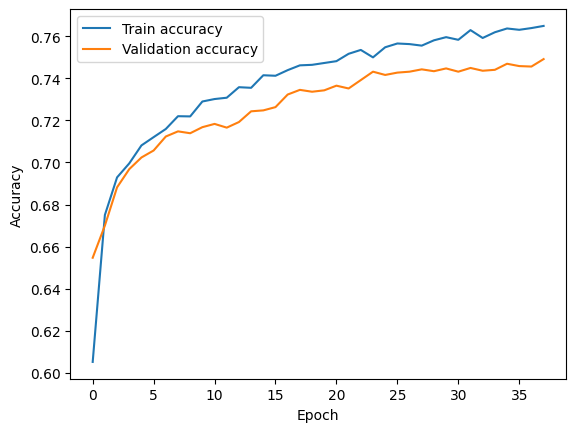

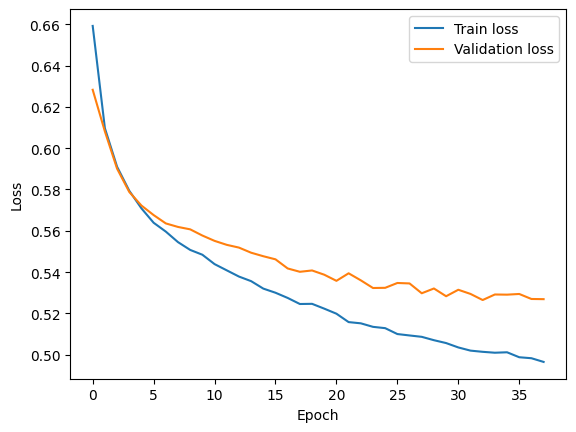

In [ ]:
#PRAĆENJE PERFORMANSI

plt.figure()
plt.plot(history_128.history["accuracy"], label="Train accuracy")
plt.plot(history_128.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history_128.history["loss"], label="Train loss")
plt.plot(history_128.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
#EVALUACIJA NA TEST SKUPU

test_loss, test_accuracy = model.evaluate(
    test_gen,
    steps=test_steps
)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7953 - loss: 0.4909
Test accuracy: 0.781050980091095
Test loss: 0.4947223961353302


In [ ]:
#Spašavanje modela

model.save("/content/drive/MyDrive/POOS projekat/resnet50_waste_classifier_128.keras")

### Rezultati:

Tačnost se povećala na oko 78%, loss je također imao poboljšanje za približno 0.4%